In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
import seaborn as sns
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import pickle

### Load the MRI and the associated probability

In [2]:
# Milepost investigated :
MP_investigated = 'MP45'

# Summary of the discretized hazard curve : 
wind_df = pd.read_excel('Discretized_mp_v4.xlsx',header = [0,1],index_col = 0)
wind_df = wind_df[MP_investigated] # Only show the milepost we're focusing on : 
Discrete_hazard_exceedances = wind_df['delta_lambda'].to_numpy()
display(wind_df)

,Midpoint MRI,3 Second Gust Midpoint Wind speed (miles per hr),delta_lambda
0,19,56.380946,0.017162
1,27,65.497865,0.013585
2,39,74.614783,0.010214
3,59,83.731702,0.007331
4,92,92.848621,0.005043
5,149,101.965540,0.003336
6,249,111.082459,0.002127
7,427,120.199378,0.001310
8,753,129.316297,0.000781
9,1367,138.433216,0.000451


In [3]:
MRI_lambdas = {}
for row in wind_df.iterrows(): 
    MRI_lambdas[str(int(row[1]['Midpoint MRI']))] = row[1]['delta_lambda']

## Load the simulation results

In [4]:
MC_results_format = 'xlsx'

In [5]:
# First, load the cmp losses
xls = pd.ExcelFile('Detailed_cmp_MC_results.xlsx')

# Now you can list all sheets in the file
xls.sheet_names

cmp_losses = {}


for sheet in xls.sheet_names : 
    df = pd.read_excel('Detailed_cmp_MC_results.xlsx', sheet_name = sheet,header = [0,1],index_col = 0).dropna()
    # Filter out bad simulation results
    df = df[~(df< 0).any(axis=1)]    
    cmp_losses[int(sheet)] = df
    
for MRI in cmp_losses.keys() :
    # Indicate the current number of simulations before removing outliers 
    print(MRI,cmp_losses[MRI].shape[0])

19 11999
27 11992
39 11990
59 11982
92 11974
149 11950
249 11889
427 11626
753 10329
1367 9986
2548 10804
4879 10148
9585 10026
19316 9639
39909 10011
84503 10822
183298 11144
407160 11179


In [6]:
# Second, load the deaggregated cmp losses
detailed_mc_results_format = 'pickle'
detailed_losses = {}

if detailed_mc_results_format == 'pickle' : 
    with open('Detailed_MC_results.pickle', 'rb') as f:
        dict_losses = pickle.load(f)    
        
    for MRI in dict_losses : 
        df = dict_losses[MRI]
        # Filter out bad simulation results
        df = df[~(df< 0).any(axis=1)]    

        detailed_losses[int(MRI)] = df

else : 
    
    xls = pd.ExcelFile('Detailed_MC_results.xlsx')

    # Now you can list all sheets in the file
    xls.sheet_names
    
    for sheet in xls.sheet_names : 
        df = pd.read_excel('Detailed_MC_results.xlsx', sheet_name = sheet,header = [0,1,2,3],index_col = 0).fillna(0)
        # Filter out bad simulation results
        df = df[~(df< 0).any(axis=1)]
        detailed_losses[int(sheet)] = df        
        
for MRI in detailed_losses.keys() : 
    print(MRI,detailed_losses[MRI].shape[0])     

19 11999
27 11994
39 11987
59 11972
92 11976
149 11965
249 11912
427 11807
753 11576
1367 11354
2548 10982
4879 10488
9585 9975
19316 9741
39909 10004
84503 10774
183298 11092
407160 11108


### Extract active LCIA indicators

In [ ]:
list_MRIs = list(detailed_losses.keys())
list_LCIA_methods = list(set(detailed_losses[list_MRIs[0]].columns.get_level_values(0)))
Amount_LCIA_methods = len(list_LCIA_methods)
print(list_MRIs)
print(list_LCIA_methods)

### Adjust simulation results to account for outliers

In [9]:
upper_bnd = 97.5
collapse_affected_MRIs = [407160,183298,84503,39909,19316]
reference_collapse_MRI = max(collapse_affected_MRIs)

In [10]:
# cmp losses

# Set outlier threshold for collapse affected MRIs :  
collapse_mask_thresholds = {}
for LCIA_method in list_LCIA_methods : 
    sub_df = cmp_losses[reference_collapse_MRI][str(LCIA_method)]['Structure losses']
    threshold = np.percentile(sub_df,upper_bnd)
    collapse_mask_thresholds[LCIA_method] = threshold
    
# Identify rows with outliers :
cmp_masks = {}
for MRI in cmp_losses.keys() : 

    mask_threshold={}
    mask_df = pd.DataFrame()    
    
    for LCIA_method in list_LCIA_methods : 
            sub_df = cmp_losses[MRI][str(LCIA_method)]['Structure losses']    
            if MRI not in collapse_affected_MRIs : 
                threshold = np.percentile(sub_df,upper_bnd)
            else : 
                threshold = collapse_mask_thresholds[LCIA_method]
        
            bool_df = (sub_df<threshold)
            bool_df.name = LCIA_method
            mask_df = pd.concat([mask_df,bool_df],axis=1)
            mask_threshold[LCIA_method] = threshold

    # Assess if any row is beyond the thresholds : 
    synthesis = mask_df.all(axis=1)
    cmp_masks[MRI] = [mask_threshold,synthesis]
    
# Cleanse simulation results of their outliers 
cleansed_cmp_losses = {}

for MRI in cmp_losses.keys() :
    df = cmp_losses[MRI]
    df = df[cmp_masks[MRI][1]]
    cleansed_cmp_losses[MRI] = df
    print(MRI,cmp_losses[MRI].shape[0]-df.shape[0])    

19 502
27 523
39 566
59 656
92 700
149 406
249 433
427 397
753 367
1367 381
2548 424
4879 432
9585 455
19316 8
39909 127
84503 378
183298 379
407160 419


In [11]:
# deaggregated cmp losses

# Set outlier threshold for collapse affected MRIs :  
collapse_mask_thresholds = {}
for LCIA_method in list_LCIA_methods : 
    sub_df = detailed_losses[reference_collapse_MRI].xs(LCIA_method,axis=1,level=0).sum(axis=1)
    threshold = np.percentile(sub_df,upper_bnd)    
    collapse_mask_thresholds[LCIA_method] = threshold    
    
# Identify rows with outliers :
deagg_masks = {}
for MRI in detailed_losses.keys() : 
    
    mask_threshold={}
    mask_df = pd.DataFrame()      

    for LCIA_method in list_LCIA_methods : 
            sub_df = detailed_losses[MRI].xs(LCIA_method,axis=1,level=0).sum(axis=1)   
            if MRI not in collapse_affected_MRIs : 
                threshold = np.percentile(sub_df,upper_bnd)
            else : 
                threshold = collapse_mask_thresholds[LCIA_method]
                   
            bool_df = (sub_df<threshold)
            bool_df.name = LCIA_method
            mask_df = pd.concat([mask_df,bool_df],axis=1)
            mask_threshold[LCIA_method] = threshold                

    # Assess if any row is beyond the thresholds : 
    synthesis = mask_df.all(axis=1)
    deagg_masks[MRI] = [mask_threshold,synthesis]
    
# Cleanse simulation results of their outliers 
cleansed_detailed_losses = {}

for MRI in detailed_losses.keys() :
    df = detailed_losses[MRI]
    df = df[deagg_masks[MRI][1]]
    cleansed_detailed_losses[MRI] = df
    print(MRI,detailed_losses[MRI].shape[0]-df.shape[0]) 

19 515
27 517
39 576
59 676
92 690
149 394
249 465
427 399
753 409
1367 427
2548 433
4879 456
9585 463
19316 10
39909 107
84503 311
183298 408
407160 410


### Make a plot : score / component within the building, factoring in MRI

In [ ]:
summary_df = pd.DataFrame()

for MRI in cleansed_cmp_losses.keys() : 
    df = cleansed_cmp_losses[MRI].T.drop('Structure losses',level = 1)

    # Properly reformat the table, as intended : 
    L1 = []
    L2 = []
    L3 = []

    for item in df.index : 
        if MC_results_format != 'pickle' : 
            L1.append(ast.literal_eval(item[0]))
        else : 
            L1.append(item[0])
        L2.append(item[1].split(',')[0].split(' ')[0])
        L3.append(item[1].split(',')[0].split(' ')[1])
        tuples = list(zip(*[L1,L2,L3]))

    re_indexer = pd.MultiIndex.from_tuples(tuples, names=[None, None,None])

    # Re-index the dataframe
    df = pd.DataFrame(df.values, index =re_indexer, columns = df.columns) 
    # Get the total across all damage states, so it is only 1 impact per component
    df = df.groupby(level =[0,1]).sum().T
    
    MC_samples_count = df.shape[0]
    
    # Create a simulation mean for the relevant MRI : 
    df = pd.DataFrame(df.sum(axis =0)/MC_samples_count*MRI_lambdas[str(MRI)], columns = [MRI])

    # Save the results to a variable :
    summary_df = pd.concat([summary_df,df],axis = 1)

summary_df = summary_df.fillna(0).sort_index()
display(summary_df)

In [ ]:
CMP_df = pd.DataFrame()

for MRI in cleansed_cmp_losses.keys() : 
    df = cleansed_cmp_losses[MRI].T.drop('Structure losses',level = 1)

    # Properly reformat the table, as intended : 
    L1 = []
    L2 = []
    L3 = []

    for item in df.index : 
        if MC_results_format != 'pickle' : 
            L1.append(ast.literal_eval(item[0]))
        else : 
            L1.append(item[0])
        L2.append(item[1].split(',')[0].split(' ')[0])
        L3.append(item[1].split(',')[0].split(' ')[1])
        tuples = list(zip(*[L1,L2,L3]))

    re_indexer = pd.MultiIndex.from_tuples(tuples, names=[None, None,None])

    # Re-index the dataframe
    df = pd.DataFrame(df.values, index =re_indexer, columns = df.columns) 
    # Get the total across all damage states, so it is only 1 impact per component
    df = df.groupby(level =[0,1]).sum().T
    
    MC_samples_count = df.shape[0]
    
    # Create a simulation mean for the relevant MRI : 
    df = pd.DataFrame(df.sum(axis =0)/MC_samples_count, columns = [MRI])

    # Save the results to a variable :
    CMP_df = pd.concat([CMP_df,df],axis = 1)

CMP_df = CMP_df.fillna(0).sort_index()
display(CMP_df)

In [ ]:
keywords_selected_LCIA_methods = ['IPCC','World+']

selected_LCIA = sorted(list(set([s for s in summary_df.index.get_level_values(0) if any(substr in s[0] for substr in keywords_selected_LCIA_methods)])))

EALs = {}

LCIA_EAL = summary_df.groupby(level = 0).sum().sum(axis =1)
LCIA_EAL

In [ ]:
selected_LCIA

In [16]:
# Ensure the order is the same as other figures
Plot_order = {
    0:'GWP',
    1:'Ecosystem',
    2:'Human'
}

Method_labels = {
    'GWP':'IPCC 2021 - GWP100',
    'Ecosystem':'IW+ (2.2.1) Ecosystem Quality',
    'Human': 'IW+ (2.2.1) Human Health'
}


Two_line_Method_labels = {
    'GWP':'IPCC 2021 \n GWP100',
    'Ecosystem':'IW+ (2.2.1) \n Ecosystem Quality',
    'Human': 'IW+ (2.2.1) \n Human Health'   
 
}


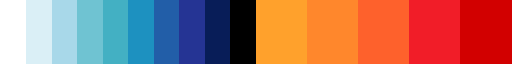

In [63]:
# Define your custom color palette
custom_listed_colors = [
    '#FFFFFF',
    '#DAEFF6',
    '#A8D8E9',
    '#6FC3D2',
    '#43B0C3',
    '#1D91C0',
'#225EA8',
'#253494',
'#081D58',
'#000000',
    

'#FFA12C', 
'#FFA12C',
'#FF872C',
'#FF872C',
'#FE612C',
'#FE612C',
'#F11D28',
'#F11D28',
'#D20000',
'#D20000',    
]

# Create a ListedColormap
custom_cmap_linear = ListedColormap(custom_listed_colors)
custom_cmap_linear.set_over('#860000')
custom_cmap_linear

In [64]:
# Add some technical details on the components : 
cmp_edp_sensibility = {
'B.20.22.001':'PID',
'B.30.11.011':'PFA',
'C.10.11.001a':'PID',
'C.30.11.001a':'PID',
'C.30.32.001a':'PFA',
'D.20.21.011a':'PFA',
'D.30.41.012a':'PFA',
'D.30.41.011a':'PFA',
'D.30.41.031a':'PFA',
'D.30.41.041a':'PFA',
'C.30.34.001':'PFA',
'D.40.11.021a':'PFA',
'D.40.11.031a':'PFA',
'C.20.11.001b':'PID',
'D.50.12.021a':'PFA',
'D.10.14.011':'PFA',
'D.30.31.011a':'PFA',
'D.30.31.021a':'PFA',
'D.30.52.011a':'PFA',
'D.50.12.013a':'PFA',
'B.10.31.001':'PID',
'B.10.31.011c':'PID',
'B.10.35.012':'PID',
'B.10.35.002':'PID',
'B.10.35.011':'PID',
'B.10.35.001':'PID',
'rebuild':'PID',
'Collapse':'PID',
}
    

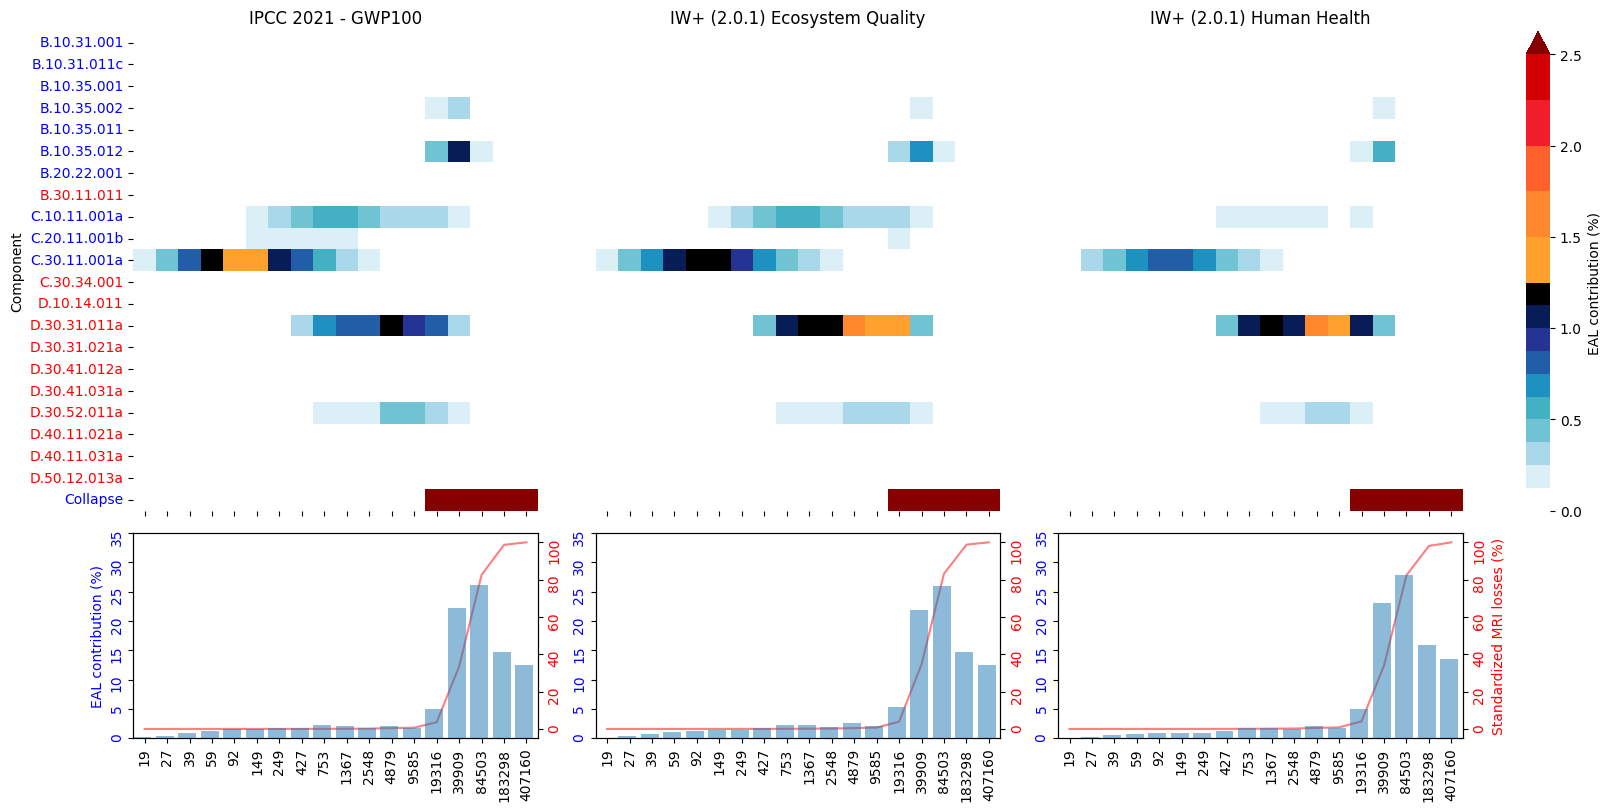

In [67]:
fig, axs = plt.subplots(2, 3, figsize = (16,8),
    gridspec_kw={'width_ratios': [1,1,1],'height_ratios':[0.7,0.3]},
                       sharex=True, sharey=False,
                       layout='constrained')


for row in range(axs.shape[0]) :     
    for col in range(axs.shape[1]) : 

        
        if (col >= 0) & (row == 0) : 
        
            lcia = [x for x in selected_LCIA if Plot_order[col] in str(x)]        
        
            normalized_ind = (summary_df.loc[lcia[0]]/LCIA_EAL[lcia[0]])*100 
            label = Method_labels[Plot_order[col]]
    
    
            axs[row,col].set_title(f'{label}') 
            cbar_max = 2.5

            if col == 0 : 
                im = sns.heatmap(normalized_ind, cmap=custom_cmap_linear, cbar =  False, ax = axs[row,col],
                                                 linewidths=0,vmin=0, vmax=cbar_max
                           )
                axs[row,col].tick_params(left=True, bottom=True)        
                axs[row,col].set_ylabel('Component')


            elif col != len(selected_LCIA)-1 :

                im = sns.heatmap(normalized_ind, cmap=custom_cmap_linear, cbar =  False, ax = axs[row,col],
                                 linewidths=0,vmin=0, vmax=cbar_max,yticklabels=False
                           )
                axs[row,col].tick_params(left=False, bottom=True)

            else : 
                im = sns.heatmap(normalized_ind, cmap=custom_cmap_linear, linewidths=0,vmin=0, vmax=cbar_max, ax = axs[row,col],
                                 yticklabels=False,
                           cbar_kws={'label': 'EAL contribution (%)','extend':'max'}                   

                           )      
                axs[row,col].tick_params(left=False, bottom=True)        
        
        
        
        if (col >= 0) & (row ==1) :
            
            MRI_losses = CMP_df.loc[lcia[0]].sum()/(CMP_df.loc[lcia[0]].sum().max())*100
            
            lcia = [x for x in selected_LCIA if Plot_order[col] in str(x)]  
            normalized_ind = ((summary_df.loc[lcia[0]]/LCIA_EAL[lcia[0]])*100).sum(axis=0)
            
            str_indexes = [str(x) for x in normalized_ind.index]

            axs[row,col].bar(str_indexes,normalized_ind.values,align='edge', alpha = 0.5)
            axs[row,col].set_ylim([0,35])
            
            axs[row,col].tick_params(labelrotation=90)
            axs[row,col].tick_params(axis='y',labelcolor='blue')
            if col == 0 : 
                axs[row,col].set_ylabel('EAL contribution (%)', color = 'blue')
                
            # Add the cumulative : 
            ax2 = axs[row,col].twinx()

            indexes = np.linspace(1,len(normalized_ind.index),num = len(normalized_ind.index))-0.5
            ax2.plot(indexes,MRI_losses.values,alpha = 0.5, color= 'red')           
            ax2.tick_params(labelcolor='red',labelrotation=90)
            if col == 2 :
                ax2.set_ylabel('Standardized MRI losses (%)', color = 'red')
                
            axs[row,col].set_zorder(ax2.get_zorder()+1)
            axs[row,col].patch.set_visible(False)
            
for l in axs[0,0].yaxis.get_ticklabels():
    label = l.get_text()
    edp_group = cmp_edp_sensibility[label]
    if edp_group == 'PFA' : 
            l.set_color(color = 'r')            
    if edp_group == 'PID' : 
            l.set_color(color= 'b')
fig.savefig('component contributions.png',dpi=300)

### Make a plot : score / story, factoring in MRI

In [ ]:
story_summary_df = pd.DataFrame()

for MRI in cleansed_detailed_losses.keys() :
    df = cleansed_detailed_losses[MRI].T
    
    # Properly reformat the table, as intended : 
    L1 = []
    L2 = []
    L3 = []
    L4 = []

    for item in df.index : 
        if MC_results_format != 'pickle' : 
            L1.append(ast.literal_eval(str(item[0])))
        else : 
            L1.append(item[0])
        L2.append(item[1])
        L3.append(item[2])
        L4.append(item[3].split('-')[0])
    
        if ('irreparable' in L4[-1]) or ('collapse' in L4[-1]) : 
            L2 = L2[:-1]
            L2.append(0)
    
        tuples = list(zip(*[L1,L2,L3,L4]))

    re_indexer = pd.MultiIndex.from_tuples(tuples, names=[None, None,None,None])
    
    # Re-index the dataframe
    df = pd.DataFrame(df.values, index =re_indexer, columns = df.columns) 
    # Get the total across all damage states, so it is only 1 impact per component
    df = df.groupby(level =[0,1]).sum().T
    
    MC_samples_count = df.shape[0]
       
    # Create a simulation mean for the relevant MRI : 
    df = pd.DataFrame(df.sum(axis =0)/MC_samples_count*MRI_lambdas[str(MRI)], columns = [MRI])

    
    # Save the results to a variable :
    story_summary_df = pd.concat([story_summary_df,df],axis = 1)

story_summary_df = story_summary_df.fillna(0).sort_index()
display(story_summary_df)

In [ ]:
story_EALs = {}
story_LCIA_EAL = story_summary_df.groupby(level = 0).sum().sum(axis =1)
print(story_LCIA_EAL)

[('IPCC 2021', 'climate change', 'global warming potential (GWP100)')]
100.00000000000001
[('IMPACT World+ Damage 2.0.1', 'Ecosystem quality', 'Total ecosystem quality')]
100.00000000000001
[('IMPACT World+ Damage 2.0.1', 'Human health', 'Total human health')]
99.99999999999999


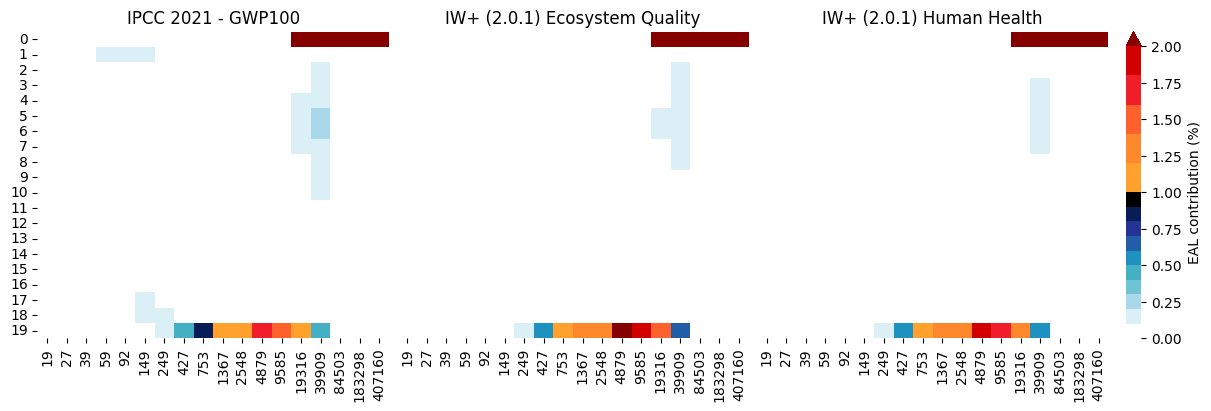

In [71]:
fig, axs = plt.subplots(1, 3,sharey=True, figsize = (12,4), layout = 'constrained')

for k, P in enumerate(Plot_order.items()):

    lcia = [x for x in selected_LCIA if P[1] in str(x)]
    print(lcia)
    
    normalized_ind = story_summary_df.loc[lcia[0]]/story_LCIA_EAL[lcia[0]]*100  
    print(normalized_ind.sum().sum())

    label = Method_labels[P[1]]   
    axs[k].set_title(f'{label}') 
    
    cbar_max = 2.0
    
    if k == 0 : 
        im = sns.heatmap(normalized_ind, cmap=custom_cmap_linear, cbar =  False, ax = axs[k],
                                         linewidths=0,vmin=0, vmax=cbar_max
                   )
    
    elif k != len(selected_LCIA)-1 :
        
        im = sns.heatmap(normalized_ind, cmap=custom_cmap_linear, cbar =  False, ax = axs[k],
                         linewidths=0,vmin=0, vmax=cbar_max
                   )
        axs[k].tick_params(left=False, bottom=True)
        
    else : 
        im = sns.heatmap(normalized_ind, cmap=custom_cmap_linear, linewidths=0,vmin=0, vmax=cbar_max, ax = axs[k],
                   cbar_kws={'label': 'EAL contribution (%)','extend':'max'}                   
                   
                   )      
        axs[k].tick_params(left=False, bottom=True)